# Debt simulation
The agents exchange a fixed amount of money and can incur debt up to a maximum limit.

In [13]:
import importlib
import functions as func
import matplotlib.pyplot as plt
import numpy as np

func = importlib.reload(func)

In [19]:
# N = 1000
# M = 3e4
# steps = 10e7
N = 3500
M = 10000
steps = 1e7

md = 50


agents = func.simulate_with_debt_shifted(
    N=N,
    M=M,
    steps=steps,
    md=md,
    transaction_type='constant'
)

print(f"Shape: {agents.shape}")
print(f"Total money: {agents.sum():.2f}")
print(f"Minimum: {agents.min():.2f}")
print(f"Maximum: {agents.max():.2f}")
print("First 10 agents:", agents[:10])

Shape: (3500,)
Total money: 10000.00
Minimum: -49.14
Maximum: 208.86
First 10 agents: [-25.14285714 -23.14285714 -35.14285714 -28.14285714 -47.14285714
  90.85714286   4.85714286 -41.14285714  27.85714286 -22.14285714]


In [20]:
print("Agents:", agents[:])

Agents: [-25.14285714 -23.14285714 -35.14285714 ... -43.14285714  67.85714286
 -22.14285714]


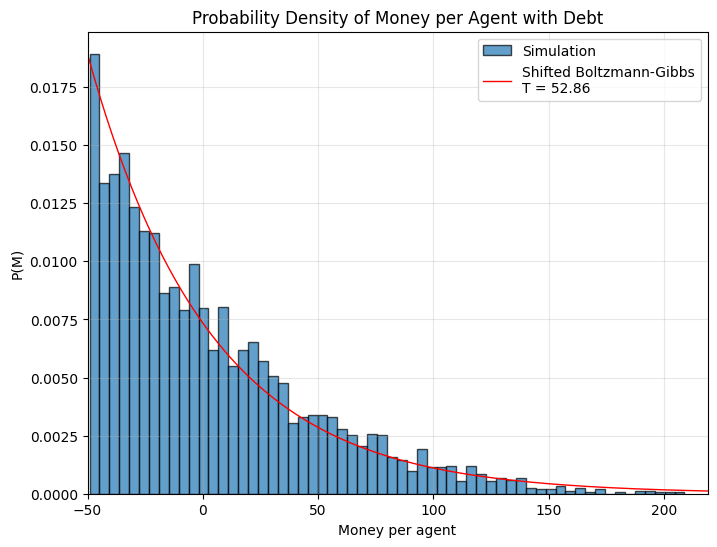

In [21]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

T_debt = M / N + md

fig, ax = plt.subplots(figsize=(8, 6))

ax.hist(
    agents,
    bins=60,
    density=True,
    alpha=0.7,
    edgecolor="black",
    label="Simulation"
)

x_fit = np.linspace(-md, agents.max() + 10, 300)
y_fit = (1 / T_debt) * np.exp(-(x_fit + md) / T_debt)

ax.plot(
    x_fit,
    y_fit,
    "r-",
    linewidth=1,
    label=f"Shifted Boltzmann-Gibbs\nT = {T_debt:.2f}"
)

ax.set_xlabel("Money per agent")
ax.set_ylabel("P(M)")
ax.set_title("Probability Density of Money per Agent with Debt")
ax.legend()
ax.grid(alpha=0.3)
ax.set_xlim(-md, agents.max() + 10)
plt.show()

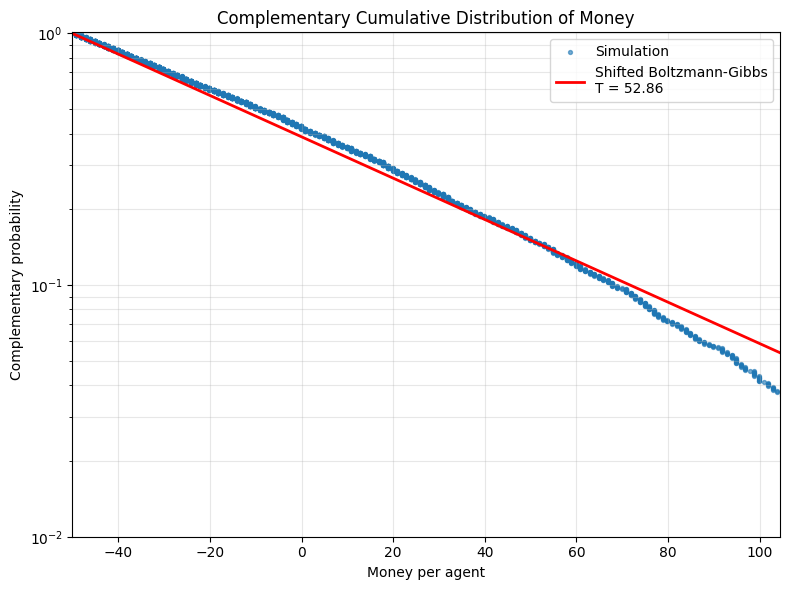

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))

sorted_agents = np.sort(agents)
probability = 1 - np.arange(1, N + 1) / N

ax.scatter(
    sorted_agents,
    probability,
    s=8,
    alpha=0.6,
    label="Simulation"
)

ax.plot(
    x_fit,
    np.exp(-(x_fit + md) / T_debt),
    "r-",
    linewidth=2,
    label=f"Shifted Boltzmann-Gibbs\nT = {T_debt:.2f}"
)

ax.set_yscale("log")
ax.set_xlabel("Money per agent")
ax.set_ylabel("Complementary probability")
ax.set_title("Complementary Cumulative Distribution of Money")
ax.legend()
ax.grid(which="both", alpha=0.3)
ax.set_xlim(-md, agents.max() / 2)
ax.set_ylim(1e-2, 1.01)

plt.tight_layout()
plt.show()

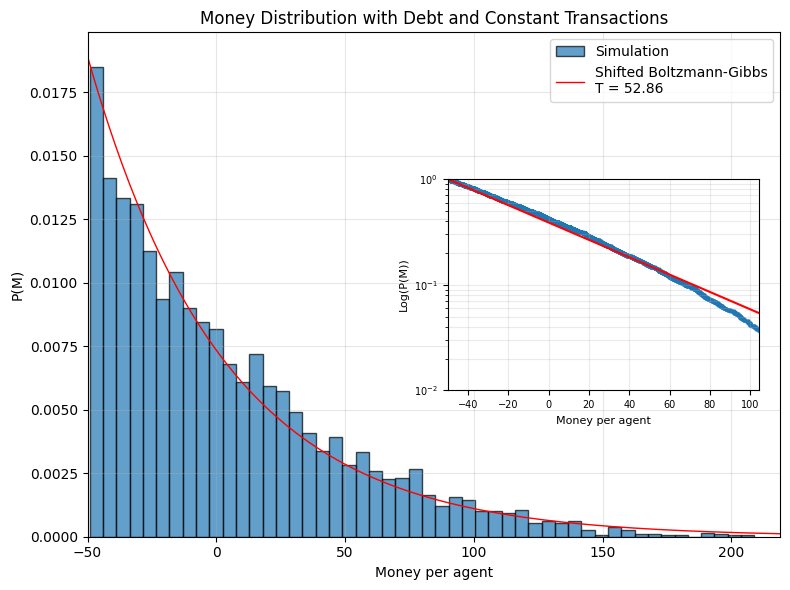

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))

# First plot: histogram and shifted Boltzmann-Gibbs distribution
ax.hist(
    agents,
    bins=50,
    density=True,
    alpha=0.7,
    edgecolor="black",
    label="Simulation"
)

ax.plot(
    x_fit,
    y_fit,
    "r-",
    linewidth=1,
    label=f"Shifted Boltzmann-Gibbs\nT = {T_debt:.2f}"
)

ax.set_xlabel("Money per agent")
ax.set_ylabel("P(M)")
ax.set_title("Money Distribution with Debt and Constant Transactions")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
ax.set_xlim(-md, agents.max() + 10)

# Second plot as a small overlay, centered vertically and shifted right
inset = ax.inset_axes([0.52, 0.29, 0.45, 0.42])

inset.scatter(
    sorted_agents,
    probability,
    s=5,
    alpha=0.6,
    color="tab:blue"
)

inset.plot(
    x_fit,
    np.exp(-(x_fit + md) / T_debt),
    "r-",
    linewidth=1.5
)

inset.set_yscale("log")
inset.set_xlim(-md, agents.max() / 2)
inset.set_ylim(1e-2, 1.01)
inset.set_xlabel("Money per agent", fontsize=8)
inset.set_ylabel("Log(P(M))", fontsize=8)
inset.tick_params(axis="both", labelsize=7)
inset.grid(which="both", alpha=0.25)

plt.tight_layout()
plt.show()